In [24]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt
%matplotlib inline

In [25]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [26]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [27]:
#building dataset

block_size = 3 #context length
X,Y = [],[]
for w in words :
   #print(w)
   context = [0] * block_size
   for ch in w + '.' :
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print (''.join(itos[i] for i in context), '-->', itos[ix])
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)



In [28]:
C = torch.randn((27,2))

In [29]:
emb = C[X]

In [30]:
C[X][13,2]

tensor([-0.4725,  0.0085])

In [31]:
C[1]

tensor([-0.4725,  0.0085])

In [32]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [33]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1)

In [34]:
h

tensor([[ 0.9520, -0.9987,  0.9986,  ..., -0.9633,  0.9797, -0.3851],
        [ 0.8417, -0.9972,  0.5420,  ...,  0.0826, -0.3137, -0.7354],
        [ 0.9955, -0.6761,  0.5128,  ...,  0.8578,  0.7939, -0.4744],
        ...,
        [ 0.9729, -0.6297, -0.9608,  ...,  0.7823, -0.0695, -0.8344],
        [ 0.5137, -0.2050, -0.8873,  ...,  0.6858,  0.9430,  0.1099],
        [ 0.9622,  0.2479,  0.8485,  ...,  0.2878,  0.9962, -0.9906]])

In [35]:
h.shape

torch.Size([228146, 100])

In [36]:
w2 = torch.randn([100,27])
b2 = torch.randn(27)

In [37]:
logits = h @ w2 + b2

In [38]:
logits.shape

torch.Size([228146, 27])

In [39]:
logits

tensor([[ -4.3229,  11.7384,   0.8555,  ...,   7.1279,   2.4254,   7.9895],
        [ -9.6418,   7.0710,  -7.5829,  ...,  -5.4050,  -2.3759,   5.1328],
        [  0.7675,   2.8932,  -1.6819,  ...,   4.6451,  -0.8870,   1.4070],
        ...,
        [ -7.5608,  -0.0889,  -4.3151,  ..., -11.3087,  -6.2910,   0.4608],
        [  3.9462,   0.9432,   0.3223,  ...,  -2.2573,   6.6475,  -5.9067],
        [  4.5953,   5.0143,  -0.8897,  ...,  11.1091,   6.9305,   3.4802]])

In [40]:
counts = logits.exp()

In [41]:
prob = counts/counts.sum(1, keepdims=True)

In [42]:
prob.shape

torch.Size([228146, 27])

In [43]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [44]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [45]:
loss = -prob[torch.arange(32), Y[:32]].log().mean()


In [46]:
loss

tensor(15.0022)

In [47]:
F.cross_entropy(logits, Y)

tensor(14.2682)

In [48]:
parameters = [C, w1, b1, w2, b2]
for p in parameters:
    p.requires_grad = True

print(f"Total parameters: {sum(p.nelement() for p in parameters)}")


Total parameters: 3481


In [59]:
g = torch.Generator().manual_seed(2147483647) # Optional: set seed for reproducible results
C = torch.randn((27, 2), generator=g)
w1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
w2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, w1, b1, w2, b2]
for p in parameters:
    p.requires_grad = True


In [60]:
lrc = torch.linspace(-3, 0, 1000)
lrs = 10 ** lrc

In [63]:
lossi = []

for i in range(10000): # e.g. 10,000 steps
    # 1. Mini-batch construct
    ix = torch.randint(0, X.shape[0], (32,))
    
    # 2. Forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
    # 3. Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # 4. Update with fixed learning rate
    lr = 0.1 if i < 5000 else 0.01  # learning rate decay after 5k steps
    for p in parameters:
        p.data += -lr * p.grad
        
    lossi.append(loss.log10().item())

print(f"Final Batch Loss: {loss.item():.4f}")


Final Batch Loss: 2.0777


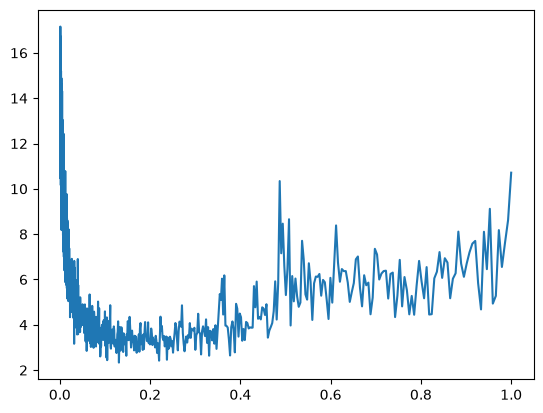

In [51]:
plt.plot(lri,lossi)

In [52]:
torch.randint(0, X.shape[0], (32,))


tensor([221224,  18220,  34794,  63397, 159875, 212776, 137406,  84114, 194658,
        131095,  30212,  46562, 124554, 143503, 157246, 224444, 166144,  87580,
        131951,  86769, 146658, 206230,  48184, 192685,  89830,  48856, 182723,
         92824, 201014,  32876, 144350, 214895])

In [ ]:
#